In [8]:
from datasets import load_dataset

# Hugging Face’den MNIST veri setini indir
dataset = load_dataset("mnist")

# Eğitim ve test setlerini ayıralım
X_train = dataset["train"]["image"]
y_train = dataset["train"]["label"]

X_test = dataset["test"]["image"]
y_test = dataset["test"]["label"]

# Veri seti boyutlarını kontrol edelim
print(f"MNIST Eğitim seti boyutu: {len(X_train)}")
print(f"MNIST Test seti boyutu: {len(X_test)}")
print(f"Örnek etiketler: {set(y_train)}")


MNIST Eğitim seti boyutu: 60000
MNIST Test seti boyutu: 10000
Örnek etiketler: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}


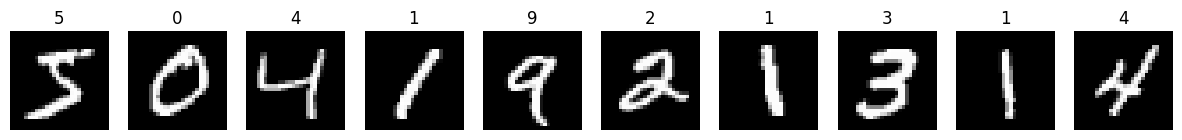

In [9]:
import matplotlib.pyplot as plt

# İlk 10 görüntüyü ve etiketlerini alalım
fig, axes = plt.subplots(1, 10, figsize=(15, 3))  # 1 satır, 10 sütunluk bir görsel alanı oluştur

for i in range(10):
    axes[i].imshow(X_train[i], cmap="gray")  # Görüntüyü siyah-beyaz göster
    axes[i].set_title(y_train[i])  # Üstüne etiketini yaz
    axes[i].axis("off")  # Eksenleri kapat

plt.show()


In [ ]:
#Let's we try LinearSVC method for analyzing the dataset but LinearSVC usually uses the dataset which have linearly releated.

In [ ]:
#First we change the data for numpy

In [11]:
import numpy as np

# Veriyi numpy array formatına çevirelim
X_train_np = np.array([np.array(img) for img in X_train])
X_test_np = np.array([np.array(img) for img in X_test])

# Şimdi flatten işlemi yapabiliriz (28x28 -> 784 vektörüne dönüştürelim)
X_train_flat = X_train_np.reshape(len(X_train_np), -1)
X_test_flat = X_test_np.reshape(len(X_test_np), -1)

print(f"Yeni Eğitim Seti Boyutu: {X_train_flat.shape}")  # (60000, 784)
print(f"Yeni Test Seti Boyutu: {X_test_flat.shape}")  # (10000, 784)


Yeni Eğitim Seti Boyutu: (60000, 784)
Yeni Test Seti Boyutu: (10000, 784)


In [15]:
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

# Pipeline: Önce veriyi ölçekleyelim, sonra modeli çalıştıralım
model = Pipeline([
    ("scaler", StandardScaler()),  # Veriyi ölçekle
    ("svm", LinearSVC(max_iter=10000))  # LinearSVC kullan
])

# Modeli eğit
print("Model eğitiliyor, bu biraz zaman alabilir...")
model.fit(X_train_flat, y_train)

# Test verisi üzerinde tahmin yap
y_pred = model.predict(X_test_flat)

# Doğruluk oranını hesapla
accuracy = accuracy_score(y_test, y_pred)
print(f"LinearSVC Model Doğruluğu: {accuracy:.4f}")


Model eğitiliyor, bu biraz zaman alabilir...
LinearSVC Model Doğruluğu: 0.9157


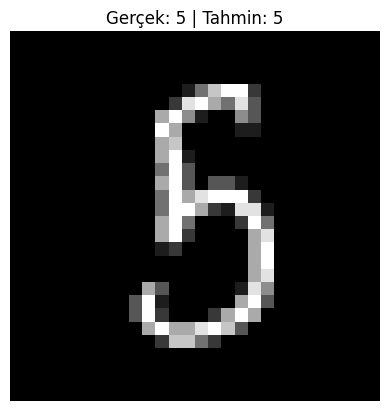

✅ Model doğru tahmin etti!


In [17]:
import random

# Test veri setinden rastgele bir örnek seçelim
index = random.randint(0, len(X_test_flat) - 1)  # 0 ile 10000 arasında rastgele bir sayı
sample_image = X_test_flat[index].reshape(1, -1)  # Modelin anlayabileceği formata çevirelim
true_label = y_test[index]  # Gerçek etiketi alalım

# Modelin tahmini
predicted_label = model.predict(sample_image)[0]

# Görselleştirelim
plt.imshow(X_test_np[index], cmap="gray")
plt.title(f"Gerçek: {true_label} | Tahmin: {predicted_label}")
plt.axis("off")
plt.show()

# Sonucu yazdıralım
if predicted_label == true_label:
    print("✅ Model doğru tahmin etti!")
else:
    print("❌ Model yanlış tahmin etti!")


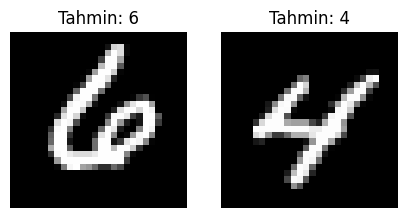

Modelin Tahmini Sayı: 64


In [18]:
# 56 gibi bir sayı göstermek için rastgele iki rakam seçelim
index1, index2 = random.randint(0, len(X_test_flat) - 1), random.randint(0, len(X_test_flat) - 1)

# İlk ve ikinci rakamı tahmin et
sample1 = X_test_flat[index1].reshape(1, -1)
sample2 = X_test_flat[index2].reshape(1, -1)

pred1 = model.predict(sample1)[0]
pred2 = model.predict(sample2)[0]

# Görüntüleri yan yana gösterelim
fig, axes = plt.subplots(1, 2, figsize=(5, 3))
axes[0].imshow(X_test_np[index1], cmap="gray")
axes[0].set_title(f"Tahmin: {pred1}")
axes[0].axis("off")

axes[1].imshow(X_test_np[index2], cmap="gray")
axes[1].set_title(f"Tahmin: {pred2}")
axes[1].axis("off")

plt.show()

# Sayıyı birleştirip gösterelim
print(f"Modelin Tahmini Sayı: {pred1}{pred2}")


In [ ]:
#SQuAD, metin parçaları üzerinden soru-cevaplama yeteneklerini değerlendirmek için kullanılan bir veri setidir. Bir paragraf ve bu paragrafa dayalı sorulardan oluşur.

In [33]:
from datasets import load_dataset

# SQuAD veri setini yükleyelim
dataset_squad = load_dataset("squad")


In [ ]:
 şimport pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
# SQuAD veri setini DataFrame'e çevirelim
df = pd.DataFrame(dataset_squad["train"])

# Sadece gerekli sütunları alalım
df = df[['context', 'question', 'answers']]

# İlk 5 satırı inceleyelim
#print(df.head())
# Veri setini ayıralım
X_train, X_test, y_train, y_test = train_test_split(df["question"], df["answers"].apply(lambda x: x["text"][0]), test_size=0.2, random_state=42)

# TF-IDF ve Naive Bayes model pipeline'ı oluşturalım
model = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("nb", MultinomialNB())
])

# Modeli eğitelim
model.fit(X_train, y_train)

# Modelin doğruluğunu hesaplayalım
accuracy = model.score(X_test, y_test)
print(f"Naive Bayes Model Doğruluğu: {accuracy:.4f}")

In [28]:
# IMDb veri setini yükleyelim
#IMDb, film yorumları ve bu yorumlara ait duygu etiketlerini içeren bir veri setidir. Duygu analizi ve metin sınıflandırma projeleri için idealdir
dataset = load_dataset("imdb")

Generating unsupervised split: 100%|██████████| 50000/50000 [00:00<00:00, 747810.40 examples/s]


In [29]:
#CIFAR-10, 10 farklı sınıfa ait küçük boyutlu (32x32 piksel) renkli görüntülerden oluşan bir veri setidir. Görüntü sınıflandırma projeleri için sıklıkla kullanılır.
# CIFAR-10 veri setini yükleyelim
dataset = load_dataset("cifar10")

Generating test split: 100%|██████████| 10000/10000 [00:00<00:00, 356201.14 examples/s]


In [31]:
from datasets import load_dataset

# GLUE görevleri ve açıklamaları
glue_tasks = {
    "cola": "CoLA: Cümlelerin dilbilgisel olarak kabul edilebilir olup olmadığını belirleme.",
    "sst2": "SST-2: Cümlelerin duygu analizini yaparak olumlu veya olumsuz olarak sınıflandırma.",
    "mrpc": "MRPC: İki cümlenin eşanlamlı olup olmadığını belirleme.",
    "stsb": "STS-B: İki cümle arasındaki anlamsal benzerliği bir ölçek üzerinde değerlendirme.",
    "qqp": "QQP: İki sorunun aynı anlama gelip gelmediğini tespit etme.",
    "mnli": "MNLI: İki cümle arasındaki ilişkinin çıkarım, çelişki veya tarafsızlık olup olmadığını belirleme.",
    "qnli": "QNLI: Bir sorunun bir cümleyle yanıtlanıp yanıtlanamayacağını tespit etme.",
    "rte": "RTE: İki cümle arasındaki çıkarım ilişkisini belirleme.",
    "wnli": "WNLI: Çözülmesi zor referans problemlerini içeren bir çıkarım görevi."
}

# Tüm veri setlerini saklayacağımız bir sözlük
glue_datasets = {}

# Her görevi indir ve açıklamasıyla birlikte göster
for task, description in glue_tasks.items():
    print(f"\n📥 '{task}' veri seti indiriliyor...")
    print(f"ℹ️ Açıklama: {description}")

    try:
        dataset = load_dataset("glue", task)
        glue_datasets[task] = dataset
        print(f"✅ '{task}' veri seti başarıyla indirildi!")
    except Exception as e:
        print(f"❌ '{task}' veri seti indirilemedi! Hata: {e}")

print("\n🎯 Tüm GLUE veri setleri başarıyla indirildi!")

# İndirilen veri setlerinden örnekleri gösterelim
for task, dataset in glue_datasets.items():
    print(f"\n📊 '{task}' veri setinden ilk 3 örnek:")
    print(dataset["train"][:3])  # İlk 3 örneği göster



📥 'cola' veri seti indiriliyor...
ℹ️ Açıklama: CoLA: Cümlelerin dilbilgisel olarak kabul edilebilir olup olmadığını belirleme.
✅ 'cola' veri seti başarıyla indirildi!

📥 'sst2' veri seti indiriliyor...
ℹ️ Açıklama: SST-2: Cümlelerin duygu analizini yaparak olumlu veya olumsuz olarak sınıflandırma.
✅ 'sst2' veri seti başarıyla indirildi!

📥 'mrpc' veri seti indiriliyor...
ℹ️ Açıklama: MRPC: İki cümlenin eşanlamlı olup olmadığını belirleme.
✅ 'mrpc' veri seti başarıyla indirildi!

📥 'stsb' veri seti indiriliyor...
ℹ️ Açıklama: STS-B: İki cümle arasındaki anlamsal benzerliği bir ölçek üzerinde değerlendirme.
✅ 'stsb' veri seti başarıyla indirildi!

📥 'qqp' veri seti indiriliyor...
ℹ️ Açıklama: QQP: İki sorunun aynı anlama gelip gelmediğini tespit etme.
✅ 'qqp' veri seti başarıyla indirildi!

📥 'mnli' veri seti indiriliyor...
ℹ️ Açıklama: MNLI: İki cümle arasındaki ilişkinin çıkarım, çelişki veya tarafsızlık olup olmadığını belirleme.
✅ 'mnli' veri seti başarıyla indirildi!

📥 'qnli' veri